In [ ]:
!pip install gym==0.23.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.2/626.2 kB 10.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for gym: filename=gym-0.23.1-py3-none-any.whl size=701458 sha256=a1170e9fa0aae063cb0fba5fb28a36e22cdfe3d6b1cf12ef0a167a7d52b518b0
  Stored in directory: /root/.cache/pip/wheels/76/3d/86/444fdf01f8cf84453dd21d0aa0c4c4835a2cf7183b810e5a53
Successfully built gym
  Attempting uninstall: gym
    Found existing installation: gym 0.25.2
    Uninstalling gym-0.25.2:
      Successfully uninstalled gym-0.25.2


In [ ]:
import gym

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
entorno = gym.make('Taxi-v3')

/usr/local/lib/python3.12/dist-packages/pygame/pkgdata.py:25: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  from pkg_resources import resource_stream, resource_exists
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-packages
  declare_namespace(pkg)
/usr/local/lib/python3.12/dist-packages/pkg_resources/__init__.py:3154: DeprecationWarning: Deprecated call to `pkg_resources.declare_namespace('google.cloud')`.
Implementing implicit namespace packages (as specified in PEP 420) is preferred to `pkg_resources.declare_namespace`. See https://setuptools.pypa.io/en/latest/references/keywords.html#keyword-namespace-pa

In [ ]:
S = entorno.reset()
entorno.render()
print('Estado inicial: {}'.format(S))
print('Numero de estados: {}'.format(entorno.observation_space.n))
print('Numero de acciones: {}'.format(entorno.action_space.n))

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+

Estado inicial: 123
Numero de estados: 500
Numero de acciones: 6


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def mostrar_estado(env,S):
  #decodeificar el estado

  tx_fil, tx_col, origen, destino = entorno.env.decode(S)
  origenes = {0: 'R(ed)', 1: 'G(reen)', 2: 'Y(ellow)', 3: 'B(lue)', 4: 'In Taxi'}
  destinos = {0: 'R(ed)', 1: 'G(reen)', 2: 'Y(ellow)', 3: 'B(lue)'}

  print(f'Ubicación del taxi (Fil, col): {tx_fil+1, tx_col+1}')
  print(f'Origen: {origenes[origen]}')
  print(f'Destino: {destinos[destino]}')

In [ ]:
mostrar_estado(entorno,S)

Ubicación del taxi (Fil, col): (2, 2)
Origen: R(ed)
Destino: B(lue)


In [ ]:
acciones = {0:'abajo', 1:'arriba', 2:'izquierda', 3:'derecha', 4:'recoger', 5:'dejar'}

A = entorno.action_space.sample()
S, R, done, info = entorno.step(A)
entorno.render()
print(A)
print(S)
print(R)
print(done)
mostrar_estado(entorno,S)

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (South)
0
223
-1
False
Ubicación del taxi (Fil, col): (3, 2)
Origen: R(ed)
Destino: B(lue)


In [ ]:
#Funcion inicializar Q nS: num estados, nA: num acciones
def inicializar_Q(nS, nA, tipo = 'ones'):
  if tipo == 'ones':
    Q = np.ones((nS, nA))
  elif tipo == 'random':
    Q = np.random.randint((nS, nA))
  return Q

In [ ]:
Q = inicializar_Q(10,5, tipo = 'ones')
print(Q.shape)
print(Q)

(10, 5)
[[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]


In [ ]:
#permite seleccionar una accion de la tabla Q usando el enfoque e-greedy
def e_greedy(s, Q, e, nA):
  if np.random.random() >= e: #prob 1- epsilon
    a = np.argmax(Q[s,:])
  else: #prob de epsiolon
    a = np.random.randint(0, nA)
  return a

In [ ]:
s = 3
e = 0.2
a = e_greedy(s, Q, e, 3)
print(f'tabla Q para s = {s}: {Q[s,:]}')
print(f'accion seleccionada para e={e}: es {a}')

tabla Q para s = 3: [1. 1. 1. 1. 1.]
accion seleccionada para e=0.2: es 0


In [ ]:
def Sarsa_onpolicy(entorno, alpha, gamma, epsilon, nS, nA, k, verbose=False):
  Q = inicializar_Q(nS, nA)
  retorno = []

  for episodio in range(k):
    retorno_acumulado = 0
    s = entorno.reset()
    a = e_greedy(s, Q, epsilon, nA)
    done = False #no estado terminal

    while not done:
      s_, r_, done, info = entorno.step(a)
      a_ = e_greedy(s_, Q, epsilon, nA)
      retorno_acumulado += r_

      if not done: #si no es estado terminal
        Q[s, a] += alpha * (r_ + gamma * Q[s_, a_] - Q[s, a])
      else:
        Q[s, a] += alpha * (r_ - Q[s, a])
        retorno.append(retorno_acumulado)
      s, a = s_, a_
      if verbose:
        if episodio%100 == 0:
          print(f'episodio {episodio+1}/{k}:')
          print(f'\t\t Recompensa {r_}')

  return Q, retorno

In [ ]:
ALPHA = 0.4 #QUE TAN IMPORTANCTE ES LA DIFERENCIA TEMPORAL
GAMMA = 0.999
EPSILON = 0.1
K = 2000
NS= entorno.observation_space.n
NA = entorno.action_space.n
Q_s, ret_s = Sarsa_onpolicy(entorno, ALPHA, GAMMA, EPSILON, NS, NA, K)

In [ ]:
#sarsa y q learning para la tarea que se esta haciendo

Text(0, 0.5, 'Retorno acumulado')

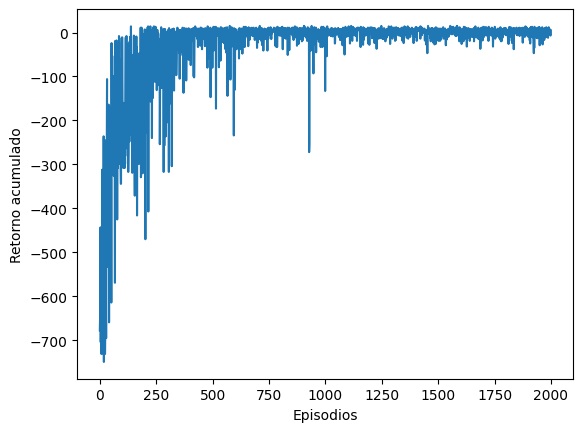

In [ ]:
plt.plot(ret_s)
plt.xlabel('Episodios')
plt.ylabel('Retorno acumulado')

AJUSTE DE HIPERPATRAMETROS

In [ ]:
def graficar_entrenamiento(retornos, titulos):
  fig, ((ax1,ax2),(ax3,ax4)) = plt.subplots(2,2, figsize=(8,4), sharex=True, sharey=True)

  ax1.plot(retornos[0])
  ax1.title.set_text(titulos[0])
  ax2.plot(retornos[1], 'tab:orange')
  ax2.title.set_text(titulos[1])
  ax3.plot(retornos[2], 'tab:green')
  ax3.title.set_text(titulos[2])
  ax4.plot(retornos[3], 'tab:red')
  ax4.title.set_text(titulos[3])

  plt.setp([ax3, ax4], xlabel = 'Episodios')
  plt.setp([ax1, ax2], ylabel = 'Retorno acumulado')

  plt.tight_layout()
  plt.show()

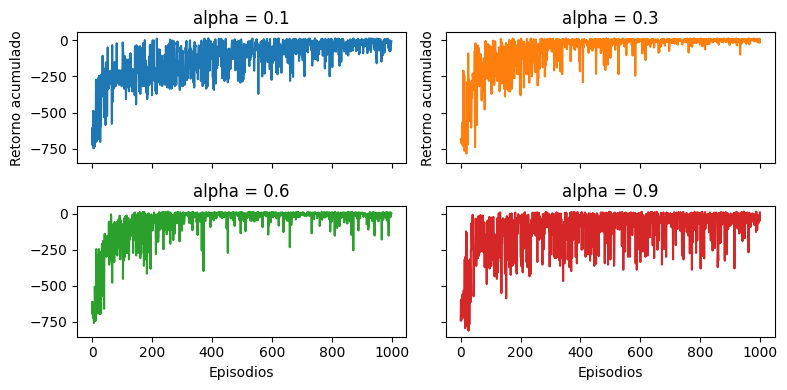

In [ ]:
#VARIAR ALPHA
Q_s1, ret_s1 = Sarsa_onpolicy(entorno, 0.1, GAMMA, EPSILON, NS, NA, K)
Q_s2, ret_s2 = Sarsa_onpolicy(entorno, 0.3, GAMMA, EPSILON, NS, NA, K)
Q_s3, ret_s3 = Sarsa_onpolicy(entorno, 0.6, GAMMA, EPSILON, NS, NA, K)
Q_s4, ret_s4 = Sarsa_onpolicy(entorno, 0.9, GAMMA, EPSILON, NS, NA, K)

#Curvas de entrenamiento
retornos = [ret_s1, ret_s2, ret_s3, ret_s4]
titulos = ['alpha = 0.1', 'alpha = 0.3', 'alpha = 0.6', 'alpha = 0.9']
graficar_entrenamiento(retornos = retornos, titulos = titulos)

0.3 converge mas rapidamente

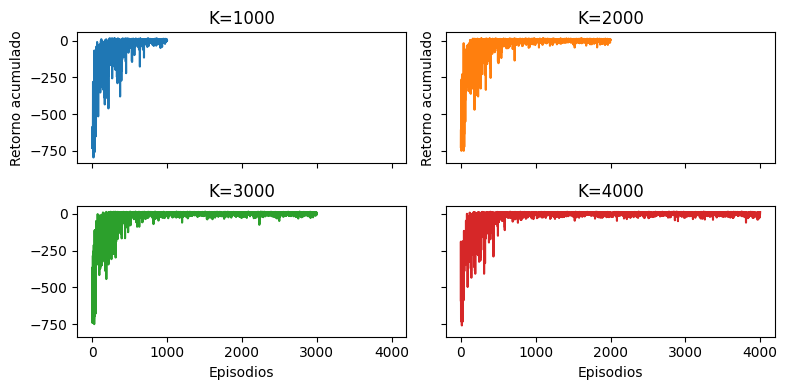

In [ ]:
#Probar con ALPHA CONSTANTE ]= 0.3 Y VARIANDO K
ALPHA = 0.3
Q_s1, ret_s1 = Sarsa_onpolicy(entorno, ALPHA, GAMMA, EPSILON, NS, NA, 1000)
Q_s2, ret_s2 = Sarsa_onpolicy(entorno, ALPHA, GAMMA, EPSILON, NS, NA, 2000)
Q_s3, ret_s3 = Sarsa_onpolicy(entorno, ALPHA, GAMMA, EPSILON, NS, NA, 3000)
Q_s4, ret_s4 = Sarsa_onpolicy(entorno, ALPHA, GAMMA, EPSILON, NS, NA, 4000)

#Curvas de entrenamiento
retornos = [ret_s1, ret_s2, ret_s3, ret_s4]
titulos = ['K=1000', 'K=2000', 'K=3000', 'K=4000']
graficar_entrenamiento(retornos = retornos, titulos = titulos)

4000 COMO BASE PARA LASD DEMAS VARIACIONES

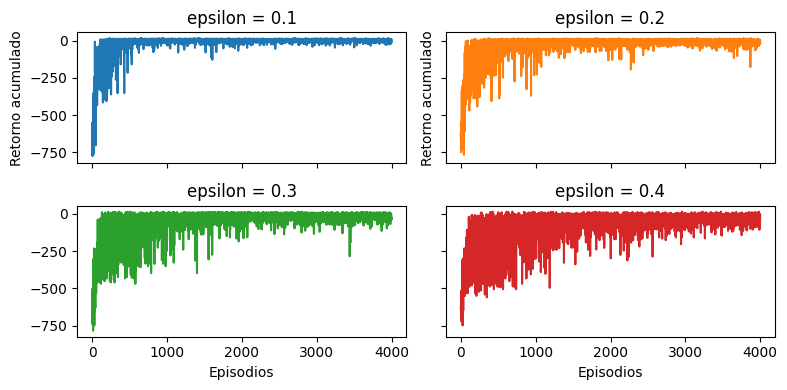

In [ ]:
#VARIAR EPSILON
K = 4000
Q_s1, ret_s1 = Sarsa_onpolicy(entorno, ALPHA, GAMMA, 0.1, NS, NA, K)
Q_s2, ret_s2 = Sarsa_onpolicy(entorno, ALPHA, GAMMA, 0.2, NS, NA, K)
Q_s3, ret_s3 = Sarsa_onpolicy(entorno, ALPHA, GAMMA, 0.3, NS, NA, K)
Q_s4, ret_s4 = Sarsa_onpolicy(entorno, ALPHA, GAMMA, 0.4, NS, NA, K)

#Curvas de entrenamiento
retornos = [ret_s1, ret_s2, ret_s3, ret_s4]
titulos = ['epsilon = 0.1', 'epsilon = 0.2', 'epsilon = 0.3', 'epsilon = 0.4']
graficar_entrenamiento(retornos = retornos, titulos = titulos)

MEJOR EPSILON -> 0.1



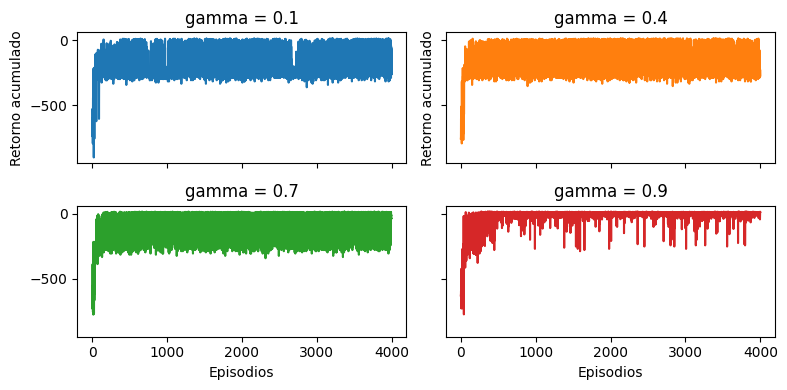

In [ ]:
#VARIAR GAMMA
EPSILON = 0.1
Q_s1, ret_s1 = Sarsa_onpolicy(entorno, ALPHA, 0.1, EPSILON, NS, NA, K)
Q_s2, ret_s2 = Sarsa_onpolicy(entorno, ALPHA, 0.4, EPSILON, NS, NA, K)
Q_s3, ret_s3 = Sarsa_onpolicy(entorno, ALPHA, 0.7, EPSILON, NS, NA, K)
Q_s4, ret_s4 = Sarsa_onpolicy(entorno, ALPHA, 0.9, EPSILON, NS, NA, K)

#Curvas de entrenamiento
retornos = [ret_s1, ret_s2, ret_s3, ret_s4]
titulos = ['gamma = 0.1', 'gamma = 0.4', 'gamma = 0.7', 'gamma = 0.9']
graficar_entrenamiento(retornos = retornos, titulos = titulos)

MEJOR GAMMA 0.9

Text(0, 0.5, 'Retorno acumulado')

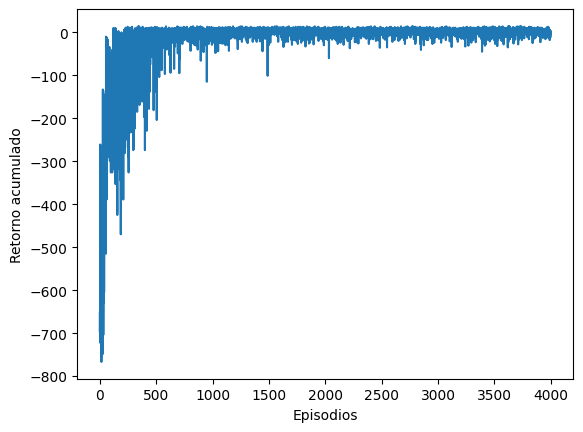

In [ ]:
#MEJORES HIPERPARAMETROS
ALPHA = 0.3
GAMMA = 0.999
EPSILON = 0.1
K = 4000
Q_sBest, ret_sBest = Sarsa_onpolicy(entorno, ALPHA, GAMMA, EPSILON, NS, NA, K)
plt.plot(ret_sBest)
plt.xlabel('Episodios')
plt.ylabel('Retorno acumulado')

Control con Q-Learning

In [ ]:
def Q_learning(entorno, alpha, gamma, epsilon, nS, nA, k, verbose=False):

  Q = inicializar_Q(nS, nA)
  retorno = []

  for episodio in range(k):
    retorno_acumulado = 0
    s = entorno.reset() #primer estado del episodio
    a = e_greedy(s, Q, epsilon, nA) #Elegir accion inicial de acuerdo a e greedy
    done = False #no estado terminal

    while not done:
      s_, r_, done, info = entorno.step(a)
      a_ = np.argmax(Q[s_, :])
      retorno_acumulado += r_

      if not done: #si no es episodio terminal
        Q[s, a] += alpha * (r_ + (gamma * Q[s_, a_]) - Q[s, a])
      else:
        Q[s, a] += alpha * (r_ - Q[s, a])
        retorno.append(retorno_acumulado)

      s, a = s_, a_
      if verbose:
        if episodio%100 == 0:
          print(f'episodio {episodio+1}/{k}:')
          print(f'\tRecompensa final {r_}')

  return Q, retorno


Text(0, 0.5, 'Retorno acumulado')

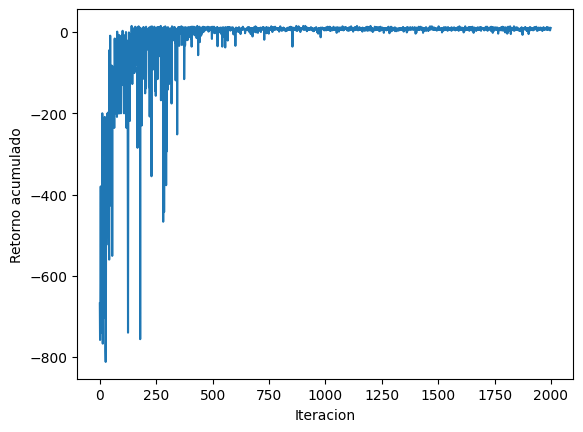

In [ ]:
ALPHA = 0.4
GAMMA = 0.999
EPSILON = 0.1
K = 2000
NS = entorno.observation_space.n
NA = entorno.action_space.n

Q_ql, ret_ql = Q_learning(entorno, ALPHA, GAMMA, EPSILON, NS, NA, K)
plt.plot(ret_ql)
plt.xlabel('Iteracion')
plt.ylabel('Retorno acumulado')

AJUSTE DE HIPERPARAMETROS PARA Q LEARNING

Text(0, 0.5, 'Retorno acumulado')

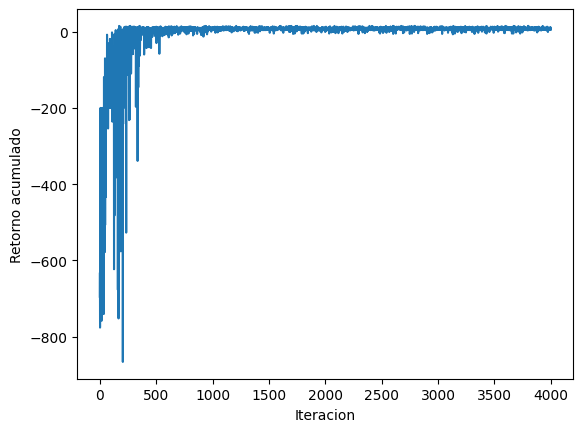

In [ ]:
ALPHA = 0.3
GAMMA = 0.999
EPSILON = 0.1
K = 4000

Q_ql1, ret_ql1 = Q_learning(entorno, ALPHA, GAMMA, EPSILON, NS, NA, K)
plt.plot(ret_ql1)
plt.xlabel('Iteracion')
plt.ylabel('Retorno acumulado')

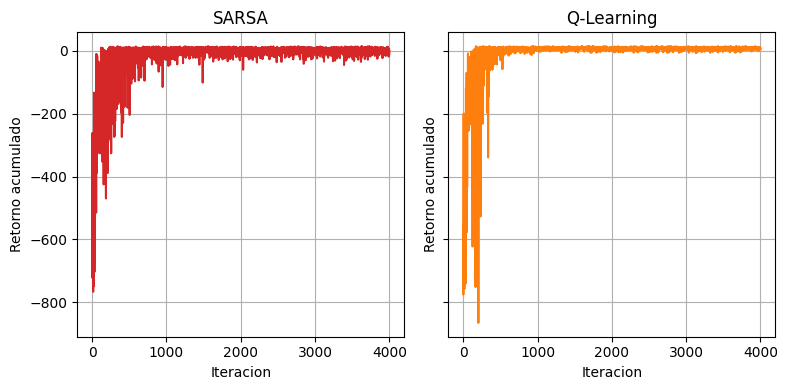

In [ ]:
fig, ((ax1,ax2)) = plt.subplots(1,2, figsize=(8,4), sharex=True, sharey=True)

ax1.plot(ret_sBest, 'tab:red')
ax1.title.set_text('SARSA')
ax1.set_xlabel('Iteracion')
ax1.grid(True)

ax2.plot(ret_ql1, 'tab:orange')
ax2.title.set_text('Q-Learning')
ax2.set_xlabel('Iteracion')
ax2.grid(True)

plt.setp([ax1, ax2], ylabel = 'Retorno acumulado')

plt.tight_layout()
plt.show()

In [ ]:
#funcion para interactuar con el entorno
def interactuar_con_ent(entorno, Q, method=None):
  it = 0
  s = entorno.reset()

  print('Resultados de la interacción: ')
  print('-'*100)

  #imprimir estado y retorno iniciales
  print('Entorno  agente al inicio: ')
  entorno.render()
  _,_,_, dest_i = entorno.env.decode(s)
  mostrar_estado(entorno, s)
  print('\n Interactuando ... \n')

  #hacer que el agente interactue con el entorno tomado como politica el maximo de la funcion Q
  a = np.argmax(Q[s, :]) #la politica
  done = False

  #interactua hasta llegar al estado terminal
  while not done:
    it += 1
    s, r, done, info = entorno.step(a)
    a = np.argmax(Q[s, :])

  _, _, _, dest_f = entorno.env.decode(s)

  if dest_i == dest_f:
    print(f'\n El episodio culminó exitosamente en {it} iteraciones')
  else:
    print(f'\n El episodio culminó en {it} iteraciones')

  print('\n Entorno agente al final: ')
  entorno.render()
  mostrar_estado(entorno, s)
  print(f'\n Recompensa obtenida: {r}')



In [ ]:
#CON SARSA
interactuar_con_ent(entorno, Q_sBest, method=None)


Resultados de la interacción: 
----------------------------------------------------------------------------------------------------
Entorno  agente al inicio: 
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+

Ubicación del taxi (Fil, col): (3, 2)
Origen: R(ed)
Destino: B(lue)

 Interactuando ... 


 El episodio culminó exitosamente en 12 iteraciones

 Entorno agente al final: 
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)
Ubicación del taxi (Fil, col): (5, 4)
Origen: B(lue)
Destino: B(lue)

 Recompensa obtenida: 20


In [ ]:
#CON QLEARNING
interactuar_con_ent(entorno, Q_ql1, method=None)

Resultados de la interacción: 
----------------------------------------------------------------------------------------------------
Entorno  agente al inicio: 
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+

Ubicación del taxi (Fil, col): (4, 1)
Origen: R(ed)
Destino: B(lue)

 Interactuando ... 


 El episodio culminó exitosamente en 12 iteraciones

 Entorno agente al final: 
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)
Ubicación del taxi (Fil, col): (5, 4)
Origen: B(lue)
Destino: B(lue)

 Recompensa obtenida: 20


EXPLORAR ENTORNO

CONTROL CON SARSA

AJUSTE DE HIPERPARAMETROS

PRIMER ENTRENAMIENTO

LUEGO CONTROL CON QLEARNING Y JUSTE DE HIPERPARAMETROS

Y COMPARAR ENTRE SARSA Y QLEARNING